# Lab - EDA Bivariate Analysis: Amazon UK Product Insights (Part II)

**Objective:** Explore the relationships between product categories, prices, ratings and best-seller status to uncover insights that can inform business strategy.

**Dataset:** `amz_uk_price_prediction_dataset.csv` ([Kaggle](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/))

> Place the CSV file in the same folder as this notebook before running.


## 0. Setup and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 110,
                     'axes.titlesize': 14, 'axes.titleweight': 'bold'})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
df = pd.read_csv('amz_uk_price_prediction_dataset.csv')

print('Rows x Columns:', df.shape)
print('Categories:', df['category'].nunique())
df.head()

Rows x Columns: (2443651, 9)
Categories: 296


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7000,15308,21.9900,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7000,98099,23.9900,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7000,15308,21.9900,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7000,7205,31.9900,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6000,1881,17.9900,False,0,Hi-Fi Speakers


---
## Part 1: Best-Seller Trends Across Product Categories

**Objective:** Understand the relationship between product categories and their best-seller status.

### 1.1 Crosstab analysis

In [3]:
# Raw counts
crosstab = pd.crosstab(df['category'], df['isBestSeller'])
print('Crosstab shape:', crosstab.shape)
crosstab.head(10)

Crosstab shape: (296, 2)


isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
Agricultural Equipment & Supplies,8421,109
Alexa Built-In Devices,106,1
Art & Craft Supplies,253,5
Arts & Crafts,9319,230


In [4]:
# Overall best-seller rate as a baseline
print('Overall best-seller rate: {:.2%}'.format(df['isBestSeller'].mean()))

# Proportion of best-sellers within each category
crosstab_prop = pd.crosstab(df['category'], df['isBestSeller'], normalize='index')

# Attach category size so we can ignore tiny categories
sizes = df['category'].value_counts()
bestseller_rate = (crosstab_prop[True]
                   .to_frame('bestseller_rate')
                   .join(sizes.rename('n_products'))
                   .query('n_products >= 50')
                   .sort_values('bestseller_rate', ascending=False))

bestseller_rate.head(15)

Overall best-seller rate: 0.33%


,bestseller_rate,n_products
category,,
Grocery,0.0581,9564
Smart Home Security & Lighting,0.0577,104
Health & Personal Care,0.0577,9569
Mobile Phone Accessories,0.0425,259
Power & Hand Tools,0.0353,8659
"Billiard, Snooker & Pool",0.0321,249
Pet Supplies,0.0302,9437
Home Brewing & Wine Making,0.0285,246
Wind Instruments,0.0280,250


**Why filter by `n_products >= 50`?** A category with 5 products and 1 best-seller shows a 20% rate, which looks impressive but is statistically meaningless. Filtering by size keeps the ranking interpretable.

In [5]:
# Categories with the lowest best-seller rates
bestseller_rate.tail(10)

,bestseller_rate,n_products
category,,
Lenses,0.0000,3138
Motorbike Electrical & Batteries,0.0000,8634
Ski Goggles,0.0000,256
Ski Helmets,0.0000,254
CPUs,0.0000,249
"CD, Disc & Tape Players",0.0000,8798
General Music-Making Accessories,0.0000,259
Snowboard Boots,0.0000,1449
Boxes & Organisers,0.0000,911


### 1.2 Statistical tests

In [6]:
chi2, p_value, dof, expected = chi2_contingency(crosstab)

print(f'Chi-square statistic : {chi2:,.2f}')
print(f'Degrees of freedom   : {dof}')
print(f'p-value              : {p_value:.6g}')

alpha = 0.05
if p_value < alpha:
    print(f'\n-> p < {alpha}: reject H0. Best-seller status is NOT independent of category.')
else:
    print(f'\n-> p >= {alpha}: fail to reject H0. No evidence of association.')

Chi-square statistic : 36,540.20
Degrees of freedom   : 295
p-value              : 0

-> p < 0.05: reject H0. Best-seller status is NOT independent of category.


In [7]:
def cramers_v(confusion_matrix):
    """Cramer's V with bias correction (Bergsma, 2013)."""
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

v = cramers_v(crosstab)
print(f"Cramer's V: {v:.4f}")

if v < 0.1:
    strength = 'negligible'
elif v < 0.2:
    strength = 'weak'
elif v < 0.4:
    strength = 'moderate'
else:
    strength = 'strong'
print(f'-> Association strength: {strength}')

Cramer's V: 0.1218
-> Association strength: weak


> **Interpretation:** With a very large sample size the Chi-square test will almost certainly return a significant p-value — statistical significance here says little about practical importance. Cramér's V is the measure that matters: it tells you *how much* category actually explains best-seller status.

### 1.3 Visualization - Stacked bar chart

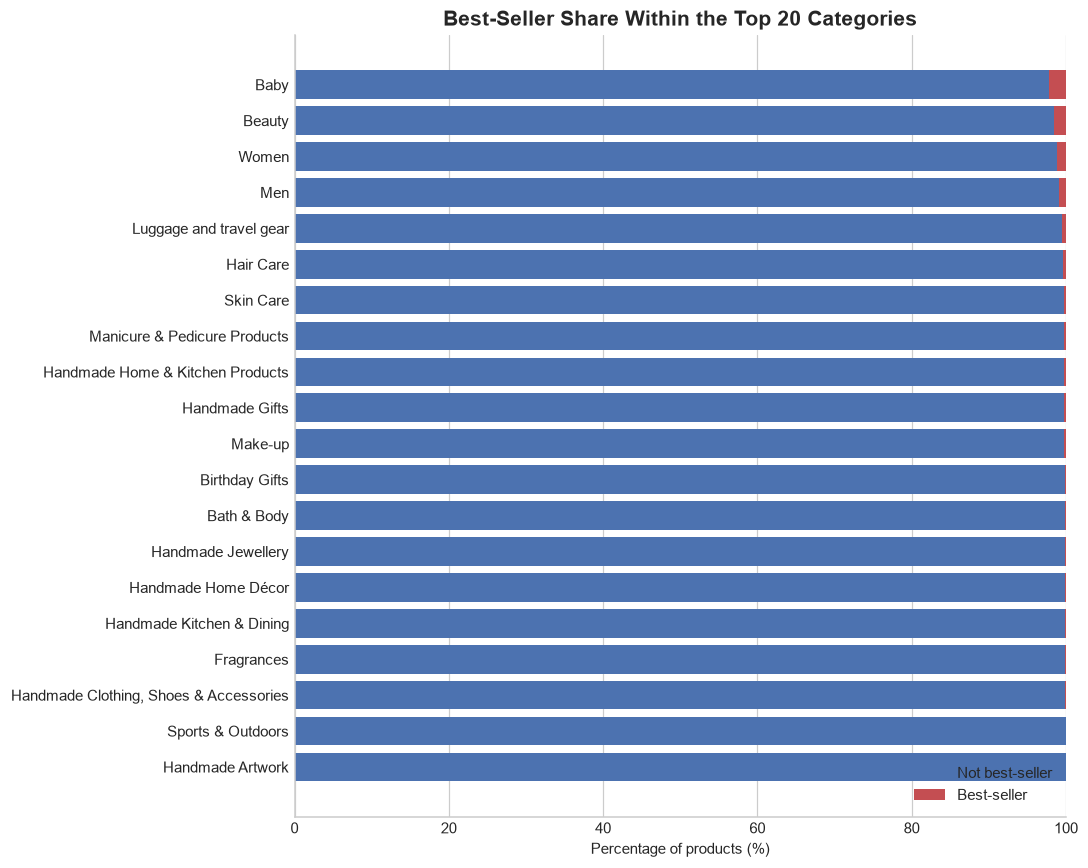

In [8]:
top20 = df['category'].value_counts().head(20).index
subset = df[df['category'].isin(top20)]

ct = pd.crosstab(subset['category'], subset['isBestSeller'], normalize='index') * 100
ct = ct.sort_values(True, ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(ct.index, ct[False], color=PALETTE[0], label='Not best-seller')
ax.barh(ct.index, ct[True], left=ct[False], color=PALETTE[3], label='Best-seller')

ax.set_title('Best-Seller Share Within the Top 20 Categories')
ax.set_xlabel('Percentage of products (%)')
ax.set_xlim(0, 100)
ax.legend(loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

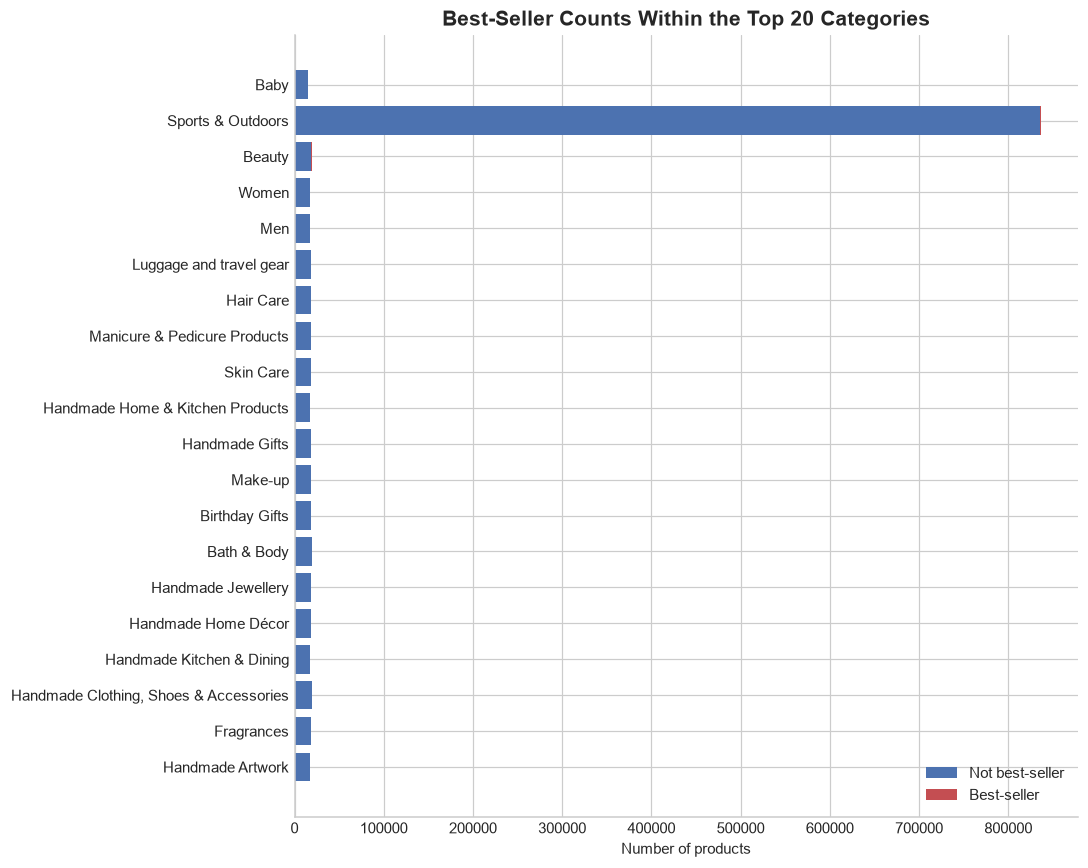

In [9]:
# Absolute counts version - the proportional view hides how small the best-seller group is
fig, ax = plt.subplots(figsize=(10, 8))
ct_abs = pd.crosstab(subset['category'], subset['isBestSeller']).sort_values(True)

ax.barh(ct_abs.index, ct_abs[False], color=PALETTE[0], label='Not best-seller')
ax.barh(ct_abs.index, ct_abs[True], left=ct_abs[False], color=PALETTE[3], label='Best-seller')
ax.set_title('Best-Seller Counts Within the Top 20 Categories')
ax.set_xlabel('Number of products')
ax.legend(loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## Part 2: Product Prices and Ratings Across Categories

**Objective:** Investigate how different product categories influence product prices.

### 2.0 Preliminary step: removing price outliers (IQR method)

Products priced below `Q1 - 1.5 x IQR` or above `Q3 + 1.5 x IQR` are treated as outliers and removed. All subsequent steps use the cleaned dataframe.

In [10]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(f'Q1     : {q1:,.2f}')
print(f'Q3     : {q3:,.2f}')
print(f'IQR    : {iqr:,.2f}')
print(f'Bounds : [{lower:,.2f}, {upper:,.2f}]')

df_clean = df[(df['price'] >= lower) & (df['price'] <= upper)].copy()

removed = len(df) - len(df_clean)
print(f'\nRows before : {len(df):,}')
print(f'Rows after  : {len(df_clean):,}')
print(f'Removed     : {removed:,} ({removed/len(df):.2%})')

Q1     : 9.99
Q3     : 45.99
IQR    : 36.00
Bounds : [-44.01, 99.99]

Rows before : 2,443,651
Rows after  : 2,115,963
Removed     : 327,688 (13.41%)


### 2.1 Violin plots

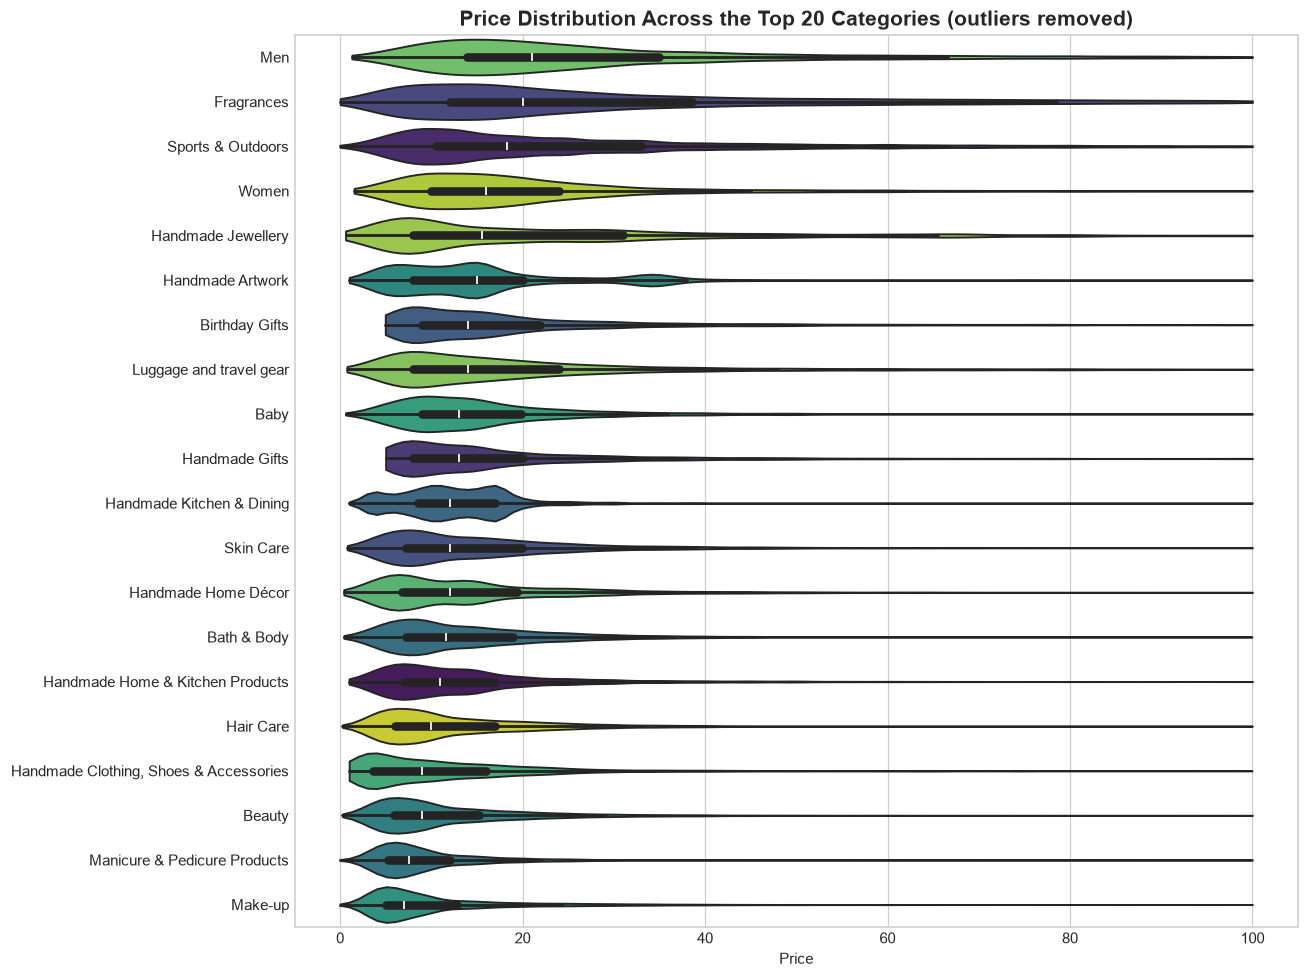

In [11]:
top20_clean = df_clean['category'].value_counts().head(20).index
subset20 = df_clean[df_clean['category'].isin(top20_clean)]

# Order categories by median price for readability
order = subset20.groupby('category')['price'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 9))
sns.violinplot(data=subset20, y='category', x='price', order=order,
               hue='category', legend=False, palette='viridis', cut=0, ax=ax)
ax.set_title('Price Distribution Across the Top 20 Categories (outliers removed)')
ax.set_xlabel('Price')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [12]:
# Highest median price across ALL categories (no top-N filter)
median_by_cat = df_clean.groupby('category')['price'].median().sort_values(ascending=False)
print('Highest median price:')
print(median_by_cat.head(10))
print(f'\n-> Top category: {median_by_cat.index[0]} ({median_by_cat.iloc[0]:,.2f})')

Highest median price:
category
Desktop PCs              74.0000
Boxing Shoes             69.7900
Tablets                  69.0000
Graphics Cards           68.5400
Motherboards             67.9200
Made in Italy Handmade   64.0000
Digital Frames           63.9000
Streaming Clients        62.6800
Golf Shoes               62.3900
Ski Helmets              61.3300
Name: price, dtype: float64

-> Top category: Desktop PCs (74.00)


### 2.2 Bar charts - average price

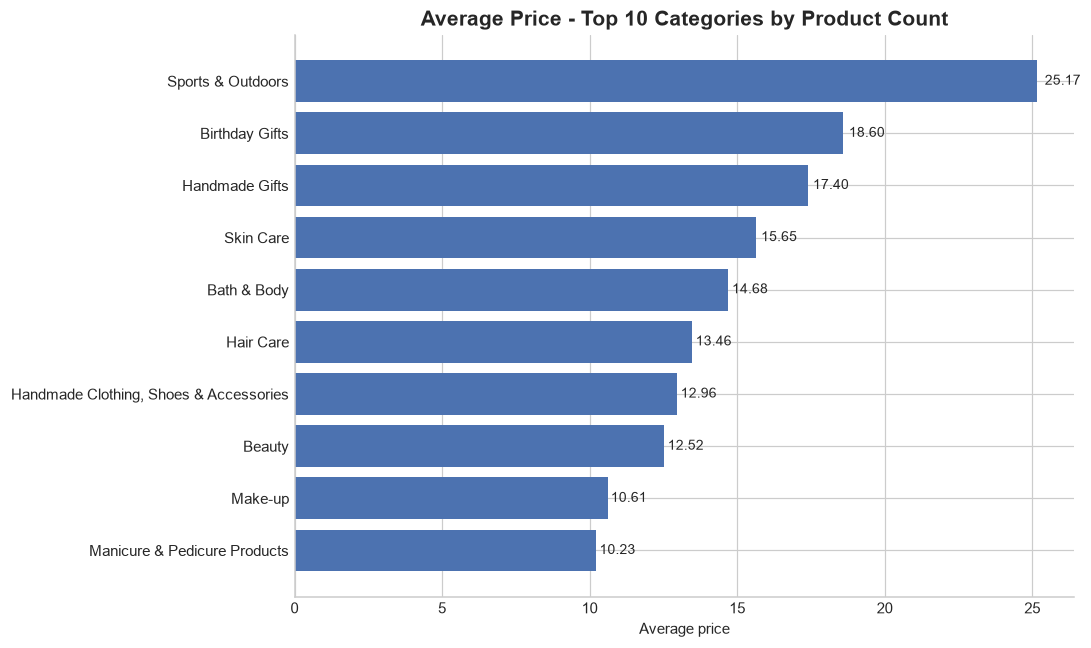

In [13]:
top10_clean = df_clean['category'].value_counts().head(10).index
avg_price_top10 = (df_clean[df_clean['category'].isin(top10_clean)]
                   .groupby('category')['price'].mean()
                   .sort_values())

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(avg_price_top10.index, avg_price_top10.values, color=PALETTE[0])
for b in bars:
    ax.text(b.get_width() * 1.01, b.get_y() + b.get_height()/2,
            f'{b.get_width():,.2f}', va='center', fontsize=9)

ax.set_title('Average Price - Top 10 Categories by Product Count')
ax.set_xlabel('Average price')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [14]:
# Highest average price across ALL categories (no top-N filter)
mean_by_cat = df_clean.groupby('category')['price'].mean().sort_values(ascending=False)
print('Highest average price:')
print(mean_by_cat.head(10))
print(f'\n-> Top category: {mean_by_cat.index[0]} ({mean_by_cat.iloc[0]:,.2f})')

Highest average price:
category
Motherboards        68.7724
Boxing Shoes        67.4178
Desktop PCs         66.9156
Tablets             66.5530
Graphics Cards      65.1035
Digital Frames      60.7451
Streaming Clients   60.2418
Hockey Shoes        60.0948
Computer Cases      58.3399
Skiing Poles        57.8678
Name: price, dtype: float64

-> Top category: Motherboards (68.77)


### 2.3 Box plots - ratings by category

Rated products: 1,114,343 (52.7% of the cleaned data)


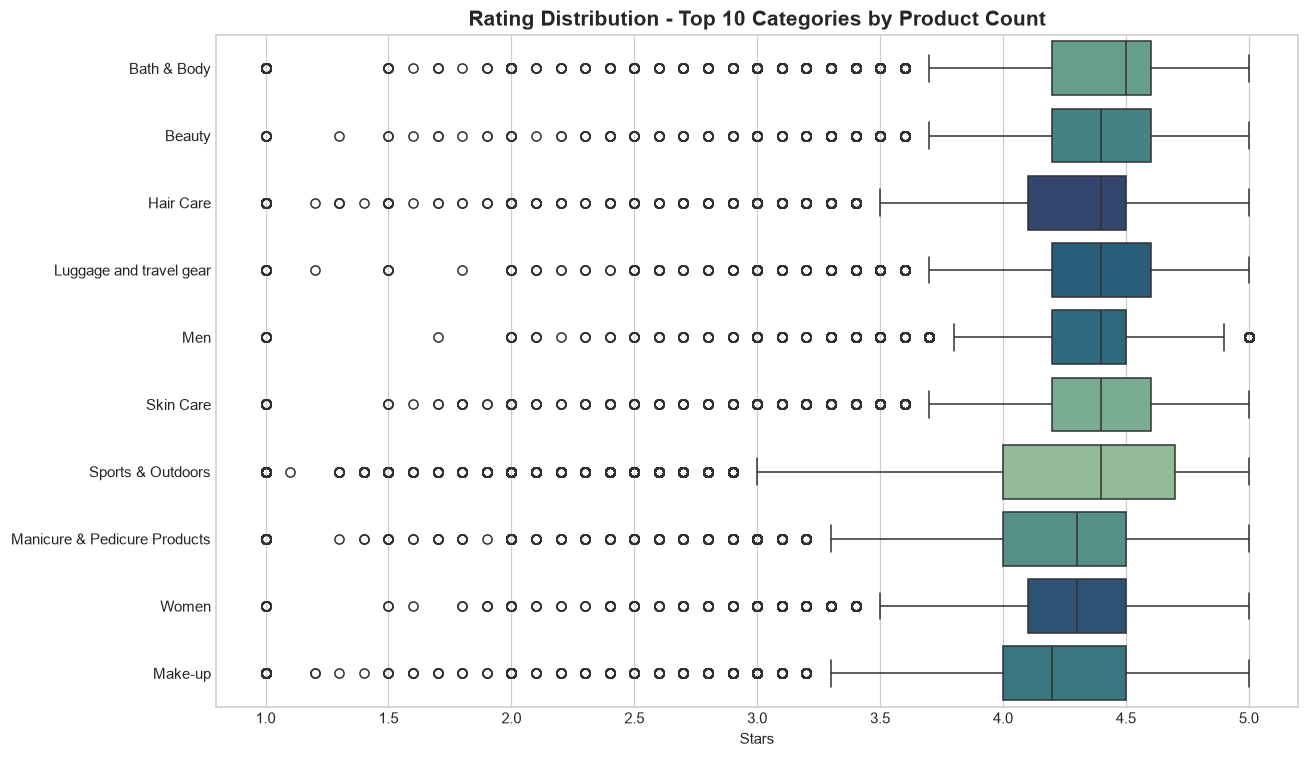

In [15]:
# Exclude unrated products: stars = 0 means "no rating yet", not a zero-star review
rated = df_clean[df_clean['stars'] > 0]
print('Rated products: {:,} ({:.1%} of the cleaned data)'.format(len(rated), len(rated)/len(df_clean)))

top10_rated = rated['category'].value_counts().head(10).index
subset10 = rated[rated['category'].isin(top10_rated)]
order_r = subset10.groupby('category')['stars'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(data=subset10, y='category', x='stars', order=order_r,
            hue='category', legend=False, palette='crest', ax=ax)
ax.set_title('Rating Distribution - Top 10 Categories by Product Count')
ax.set_xlabel('Stars')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [16]:
# Highest median rating across ALL categories (min 50 rated products)
median_rating = (rated.groupby('category')['stars']
                 .agg(['median', 'count'])
                 .query('count >= 50')
                 .sort_values('median', ascending=False))
print('Highest median rating:')
median_rating.head(10)

Highest median rating:


,median,count
category,,
Handmade Baby Products,5.0000,1235
Made in Italy Handmade,5.0000,303
Handmade Artwork,5.0000,4155
Handmade Kitchen & Dining,4.9000,2739
"Handmade Clothing, Shoes & Accessories",4.9000,4429
Birthday Gifts,4.8000,7875
Handmade Gifts,4.8000,9871
Handmade Home Décor,4.8000,7966
Handmade Home & Kitchen Products,4.7000,10722


---
## Part 3: The Interplay Between Product Prices and Ratings

**Objective:** Analyze how product ratings correlate with product prices.

### 3.1 Correlation coefficients

In [17]:
corr_df = df_clean[df_clean['stars'] > 0]

pearson_r, pearson_p = stats.pearsonr(corr_df['price'], corr_df['stars'])
spearman_r, spearman_p = stats.spearmanr(corr_df['price'], corr_df['stars'])

print(f'Pearson  r = {pearson_r:.4f}  (p = {pearson_p:.4g})')
print(f'Spearman r = {spearman_r:.4f}  (p = {spearman_p:.4g})')

abs_r = abs(pearson_r)
if abs_r < 0.1:
    strength = 'negligible'
elif abs_r < 0.3:
    strength = 'weak'
elif abs_r < 0.5:
    strength = 'moderate'
else:
    strength = 'strong'
print(f'\n-> Linear relationship: {strength}')

Pearson  r = 0.0067  (p = 1.081e-12)
Spearman r = 0.0247  (p = 1.978e-149)

-> Linear relationship: negligible


> **Note:** Pearson measures linear association and assumes roughly normal data; Spearman is rank-based and robust to skew, so it is the safer read for this dataset. As with the Chi-square test, a tiny p-value with a near-zero coefficient reflects sample size, not a meaningful relationship.

### 3.2 Visualizations - Scatter plot

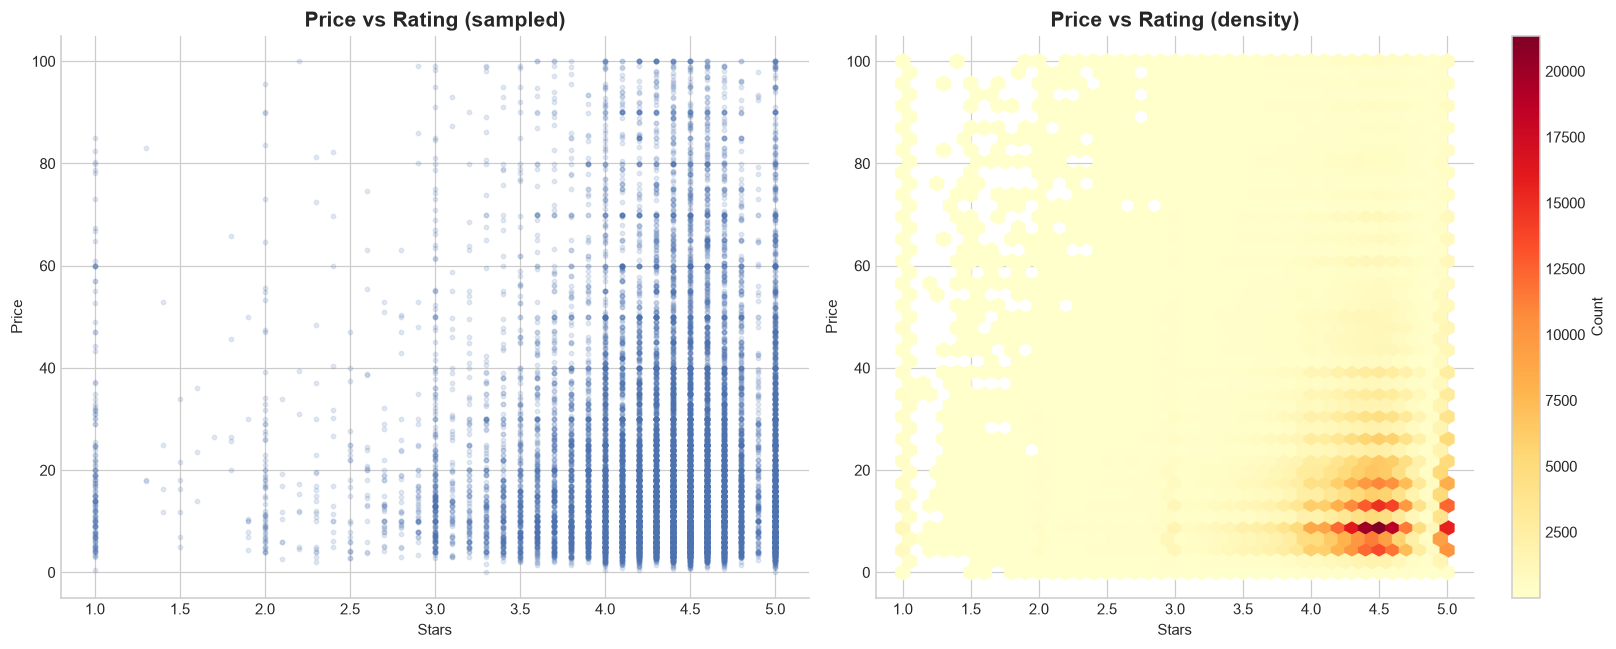

In [18]:
sample = corr_df.sample(n=min(20000, len(corr_df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(sample['stars'], sample['price'], alpha=0.15, s=8, color=PALETTE[0])
axes[0].set_title('Price vs Rating (sampled)')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Price')

# Hexbin handles overplotting far better than a scatter with this many points
hb = axes[1].hexbin(corr_df['stars'], corr_df['price'], gridsize=40, cmap='YlOrRd', mincnt=1)
axes[1].set_title('Price vs Rating (density)')
axes[1].set_xlabel('Stars')
axes[1].set_ylabel('Price')
plt.colorbar(hb, ax=axes[1], label='Count')

for a in axes:
    a.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [19]:
# Mean price by rating band - easier to read than a raw scatter
bands = pd.cut(corr_df['stars'], bins=[0, 2, 3, 3.5, 4, 4.5, 5],
               labels=['0-2', '2-3', '3-3.5', '3.5-4', '4-4.5', '4.5-5'])
band_summary = corr_df.groupby(bands, observed=True)['price'].agg(['mean', 'median', 'count'])
band_summary

,mean,median,count
stars,,,
0-2,22.6505,15.0300,12352
2-3,21.7200,14.8800,24530
3-3.5,21.6496,14.6900,39380
3.5-4,21.9451,14.9900,152641
4-4.5,21.4657,14.9900,508451
4.5-5,22.3486,15.9500,376989


### 3.3 Correlation heatmap

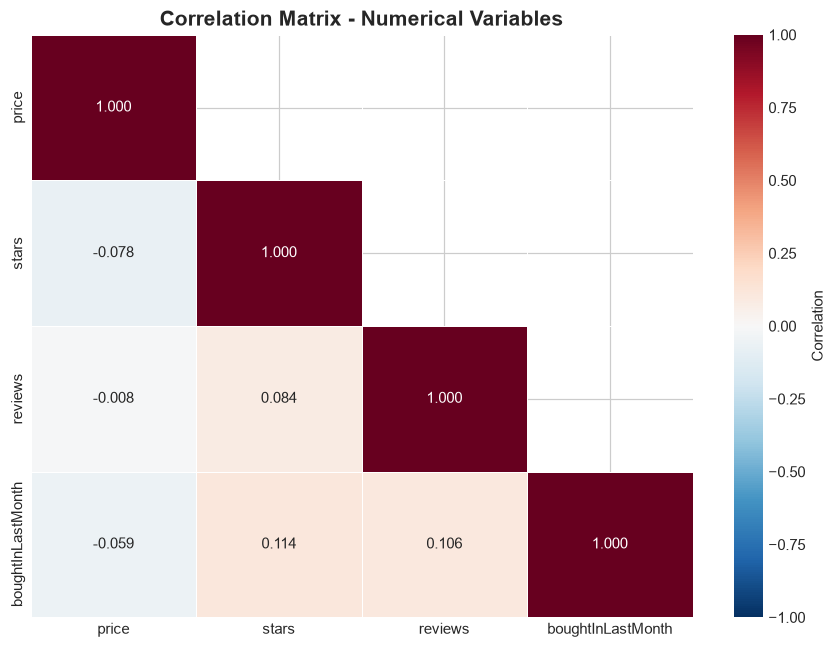

In [20]:
num_cols = ['price', 'stars', 'reviews', 'boughtInLastMonth']
num_cols = [c for c in num_cols if c in df_clean.columns]

corr_matrix = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5, mask=mask, ax=ax,
            cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix - Numerical Variables')
plt.tight_layout()
plt.show()

### 3.4 QQ plot - are prices normally distributed?

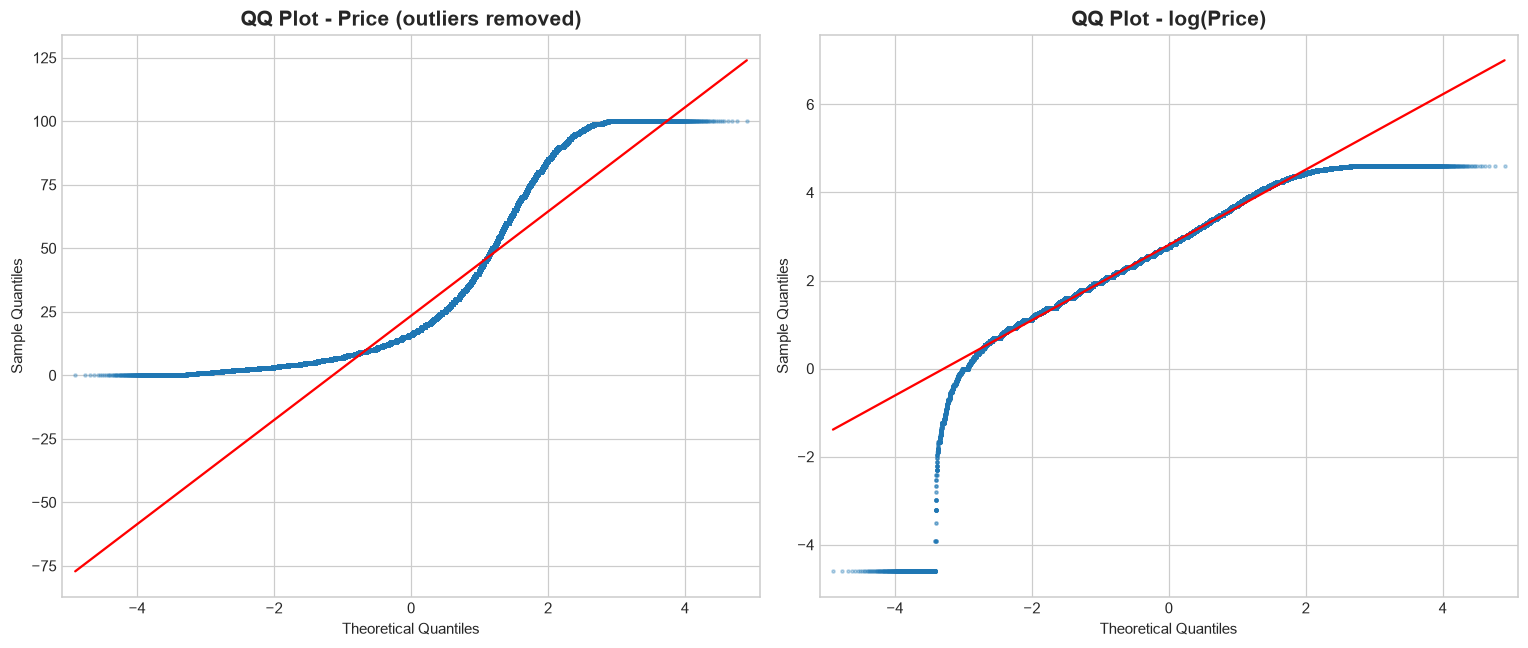

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sm.qqplot(df_clean['price'], line='s', ax=axes[0], markersize=2, alpha=0.3)
axes[0].set_title('QQ Plot - Price (outliers removed)')

positive = df_clean.loc[df_clean['price'] > 0, 'price']
sm.qqplot(np.log(positive), line='s', ax=axes[1], markersize=2, alpha=0.3)
axes[1].set_title('QQ Plot - log(Price)')

plt.tight_layout()
plt.show()

In [22]:
# Formal normality check on a sample (Shapiro-Wilk is limited to ~5000 observations)
sample_price = df_clean['price'].sample(n=min(5000, len(df_clean)), random_state=42)
stat, p = stats.shapiro(sample_price)
print(f'Shapiro-Wilk statistic : {stat:.4f}')
print(f'p-value                : {p:.4g}')
print('-> Not normally distributed.' if p < 0.05 else '-> Consistent with normality.')

print(f'\nSkewness : {df_clean["price"].skew():.3f}')
print(f'Kurtosis : {df_clean["price"].kurt():.3f}')

Shapiro-Wilk statistic : 0.8164
p-value                : 5.53e-60
-> Not normally distributed.

Skewness : 1.638
Kurtosis : 2.289


> **Reading a QQ plot:** if the points follow the diagonal reference line, the data is normally distributed. Systematic curvature away from the line — especially at the upper tail — indicates right skew. Compare the raw and log-transformed panels to see how much the transformation helps.

---
## Business-Centric Summary Report

> Fill in the blanks below using the outputs from the cells above.

### 1. Best-sellers and categories
- Overall best-seller rate across the catalogue: **__%**.
- Categories with the highest best-seller share: `...`
- Chi-square test: p = **__** → the association is statistically significant.
- Cramér's V = **__** → the association is **__** in strength.
- **Business implication:** although the test is significant, the effect size shows category alone explains only a small part of best-seller status. Product-level factors (price, review volume, rating) matter more than which category a product sits in. Sample size inflates significance here, so the effect size is the number to act on.

### 2. Prices across categories
- The IQR filter removed **__** products (**__%** of the data).
- Highest median price: **__**; highest average price: **__**.
- Median and mean rankings differ because averages remain sensitive to skew even after outlier removal.
- **Business implication:** price positioning varies sharply between categories. A single catalogue-wide pricing rule would misprice premium categories; margin targets should be set per category.

### 3. Ratings across categories
- Highest median rating: **__**.
- Ratings cluster tightly in the 4.0–4.7 band across nearly every category (ceiling effect).
- **Business implication:** ratings barely differentiate products because almost everything scores high. Review *volume* is likely a stronger trust signal than the score itself.

### 4. Price–rating relationship
- Pearson r = **__**, Spearman r = **__** → the relationship is **__**.
- **Business implication:** price does not predict customer satisfaction. Expensive products are not rated better, so a premium pricing strategy cannot rely on ratings as justification. Quality perception has to be built through other levers.

### 5. Distribution shape
- The QQ plot shows prices deviate from normality, with clear right skew.
- **Implication for modelling:** methods assuming normality require a log transform, or non-parametric alternatives should be used instead.

### Limitations
- `stars = 0` was treated as missing data rather than a genuine zero rating.
- The IQR filter removed genuinely expensive products, so conclusions do not extend to the premium segment.
- The dataset is a single snapshot; no causal or temporal claims can be made.
- Prices are listing prices and exclude promotions and discounts.
